In [ ]:
# Assessing Credit Risk

## Part 1: set-up, visualize and pre - process the data 

In [ ]:
#import the required packages

In [13]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn import tree
import warnings 

warnings.filterwarnings("ignore")
df = pd.read_csv('Data_Assignment.csv')
df.head(10)

,loan_amnt,int_rate,installment,annual_inc,last_pymnt_amnt,tot_cur_bal,loan_status
0,18600,10.99,608.86,80000.00,15705.09,170238.0,Fully Paid
1,2000,17.97,72.28,55400.00,72.28,351452.0,Current
2,12000,12.29,400.24,60000.00,11281.15,18207.0,Fully Paid
3,16000,19.42,589.90,64000.00,589.90,12293.0,Current
4,22525,16.02,548.01,94080.00,21483.11,571244.0,Fully Paid
5,19000,16.99,472.10,65000.00,472.10,13167.0,Charged Off
6,6000,9.17,191.28,147000.00,152.92,2686.0,Fully Paid
7,17000,5.32,511.96,75000.00,511.96,191633.0,Current
8,26375,24.50,766.43,71596.18,14426.38,273060.0,Fully Paid
9,10000,18.45,256.39,48000.00,256.39,132034.0,Current


In [ ]:
#load the data file

In [15]:
df

,loan_amnt,int_rate,installment,annual_inc,last_pymnt_amnt,tot_cur_bal,loan_status
0,18600,10.99,608.86,80000.0,15705.09,170238.0,Fully Paid
1,2000,17.97,72.28,55400.0,72.28,351452.0,Current
2,12000,12.29,400.24,60000.0,11281.15,18207.0,Fully Paid
3,16000,19.42,589.90,64000.0,589.90,12293.0,Current
4,22525,16.02,548.01,94080.0,21483.11,571244.0,Fully Paid
...,...,...,...,...,...,...,...
226062,5000,7.21,154.87,46000.0,154.87,37430.0,Current
226063,35000,21.85,963.68,70000.0,963.68,217083.0,Current
226064,1200,18.99,43.99,90000.0,1197.23,76125.0,Fully Paid
226065,12000,8.90,381.04,35000.0,9983.17,26386.0,Fully Paid


In [ ]:
#visualize the data. Hint: make plots using the predictors and NOT the target variable "loan_status". 

In [17]:
import seaborn as sns 

<Axes: xlabel='installment', ylabel='Count'>

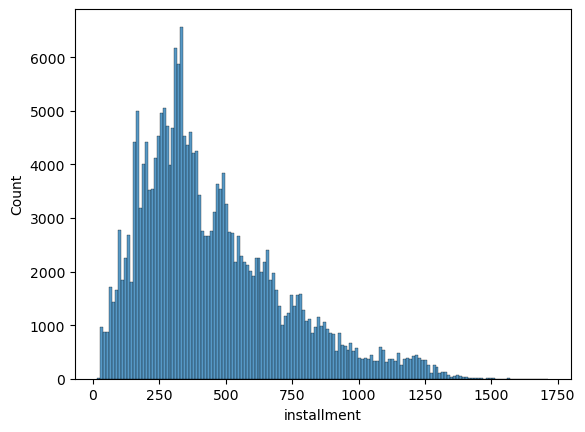

In [19]:
sns.histplot(df["installment"])

In [21]:
import matplotlib.pyplot as plt 
import seaborn as sns 

<Axes: >

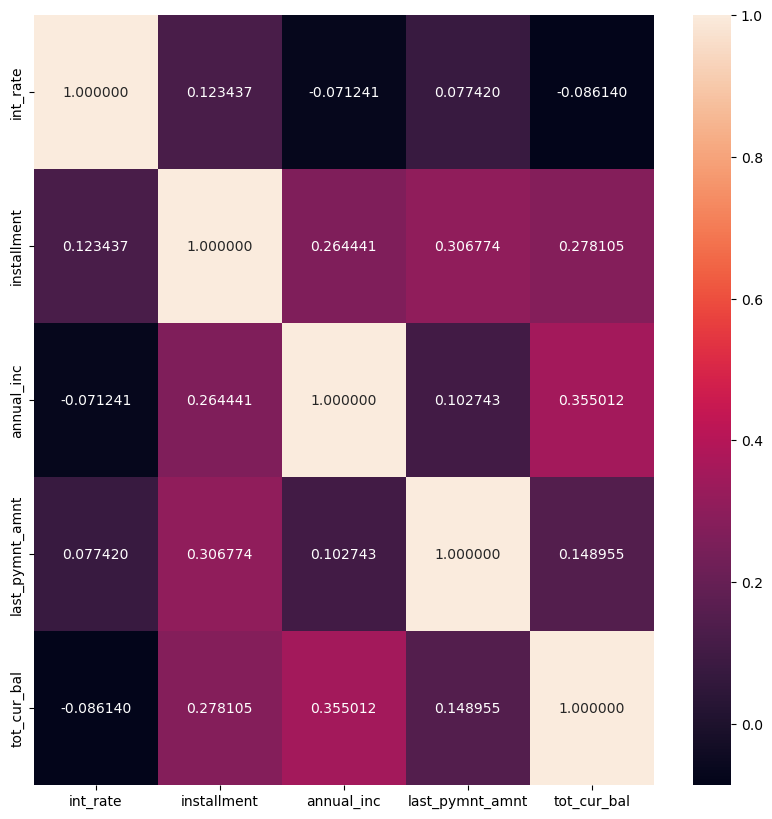

In [23]:
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(df[["int_rate","installment","annual_inc","last_pymnt_amnt","tot_cur_bal"]].corr(),annot = True, fmt = "2f", ax = ax)

In [25]:
df.isnull().sum()

loan_amnt             0
int_rate              0
installment           0
annual_inc            0
last_pymnt_amnt       0
tot_cur_bal        7107
loan_status           0
dtype: int64

In [29]:
df['tot_cur_bal'].fillna(df['tot_cur_bal'].mean(),inplace=True)
df.isnull().sum()

loan_amnt          0
int_rate           0
installment        0
annual_inc         0
last_pymnt_amnt    0
tot_cur_bal        0
loan_status        0
dtype: int64

In [ ]:
#create the dummy variable "loan_dummy". The variable we want to predict is loan_status. 
#In particular, we want to predict the probability that a mortgage is Charged Off from the bank book. Please see the code below 
#for extra help. The variable "loan_status" contains many different categories. Our focus is on the "Charged off" category. 
#You can create a dummy where "Charged off" equals 1, otherwise 0. (note: df is the name of the dataframe).
#Hint: you can use the code below to create the dummy.

In [31]:
df["loan_dummy"] = np.where(df["loan_status"] == "Charged Off", 1, 0)
#dummy = {"No": 0, "Yes": 1}

In [33]:
#df = df.replace('loan_dummy')
df.head(10)

,loan_amnt,int_rate,installment,annual_inc,last_pymnt_amnt,tot_cur_bal,loan_status,loan_dummy
0,18600,10.99,608.86,80000.00,15705.09,170238.0,Fully Paid,0
1,2000,17.97,72.28,55400.00,72.28,351452.0,Current,0
2,12000,12.29,400.24,60000.00,11281.15,18207.0,Fully Paid,0
3,16000,19.42,589.90,64000.00,589.90,12293.0,Current,0
4,22525,16.02,548.01,94080.00,21483.11,571244.0,Fully Paid,0
5,19000,16.99,472.10,65000.00,472.10,13167.0,Charged Off,1
6,6000,9.17,191.28,147000.00,152.92,2686.0,Fully Paid,0
7,17000,5.32,511.96,75000.00,511.96,191633.0,Current,0
8,26375,24.50,766.43,71596.18,14426.38,273060.0,Fully Paid,0
9,10000,18.45,256.39,48000.00,256.39,132034.0,Current,0


In [ ]:
#define the target variable y and the predictor x. For the target variable we use the dummy "loan_dummy" and for the predictors 
#we use all the other variables of your dataset. 

In [35]:
x = df[['int_rate','installment','annual_inc','last_pymnt_amnt','tot_cur_bal']]
y = df['loan_dummy']

In [ ]:
#standardize your predictors. Hint: from sklearn.preprocessing import StandardScaler

In [37]:
from sklearn.preprocessing import StandardScaler
x_std = StandardScaler().fit_transform(x)

In [ ]:
#Before estimating the logistic regression and the other models, we need to split the sample in training vs testing observations.
#split your data in training and testing. You can choose the proportion you want for the spliting. 

In [39]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_std, y, test_size=0.2, random_state=42, stratify=y)

## Part 2: Logistic regression and classification tree without cross validation

In [ ]:
#estimating the logistic regression

In [41]:
from sklearn.linear_model import LogisticRegression
logit = LogisticRegression( fit_intercept = False).fit(x_train, y_train)
yhat = logit.predict(x_test)

In [ ]:
#calculate the confusion matrix

In [43]:
from sklearn import metrics
print(metrics.confusion_matrix(y_test, yhat))

[[21865 18129]
 [  770  4450]]


In [ ]:
#Calculate now the forecast from a "no-skill" prediction and the probabilities of the logistic regression

In [45]:
# generate a no skill prediction (majority class)
ns_probs = [0 for _ in range(len(y_test))]

# generate the predicted probabilities from the logistic regression
lr_probs = logit.predict_proba(x_test)[:,1]

In [ ]:
#compare the logistic regression with the "no-skill" prediction based on the ROC curve.  

In [47]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

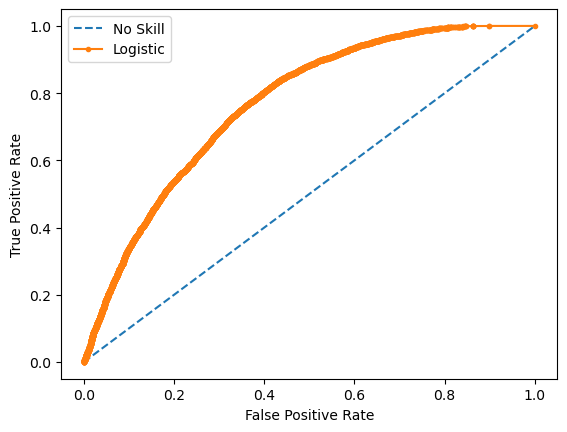

In [49]:
import matplotlib.pyplot as plt
# Visualisation with plot_metric

ns_fpr, ns_tpr, _ = roc_curve(y_test, ns_probs)
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)

# plot the roc curve for the model
plt.plot(ns_fpr, ns_tpr, linestyle='--', label='No Skill')
plt.plot(lr_fpr, lr_tpr, marker='.', label='Logistic')

# axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

# show the legend
plt.legend()

# show the plot 
plt.show()

In [ ]:
#calculate the Area Under the Curve - AUC metric of the logistic regression model

In [51]:
ns_auc = roc_auc_score(y_test, ns_probs)
lr_auc = roc_auc_score(y_test, lr_probs)

# summarize scores
print('No Skill: ROC AUC=%.3f' % (ns_auc))
print('Logistic: ROC AUC=%.3f' % (lr_auc))

No Skill: ROC AUC=0.500
Logistic: ROC AUC=0.768


In [ ]:
#estimating the classification tree without cross validation

In [53]:
from sklearn.tree import DecisionTreeClassifier

# make an instance of the model
my_tree = DecisionTreeClassifier(random_state = 42) 

# Training the model on the data, storing the information learned from the data
my_tree.fit(x_train, y_train)


DecisionTreeClassifier(random_state=42)

In [55]:
#get the predicted values
y_dt_pred = my_tree.predict(x_test)

In [57]:
#calculating the score of the model
score = my_tree.score(x_test, y_test)
print(score)

0.8471933471933472


In [ ]:
#calculate the confusion matrix of the tree

In [59]:
from sklearn import metrics
conf_matrix = metrics.confusion_matrix(y_test, y_dt_pred)
print(conf_matrix)

[[36415  3579]
 [ 3330  1890]]


Text(0.5, -0.6000000000000014, 'Predicted')

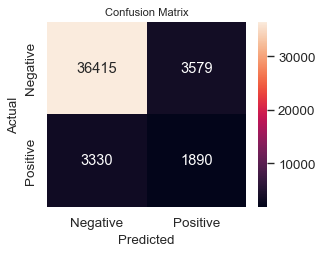

In [61]:
import seaborn as sns
plt.figure(figsize=(4,3), dpi=80)
sns.set(font_scale = 1.1)

ax = sns.heatmap(conf_matrix, annot=True, fmt='d', )
ax.xaxis.set_ticklabels(['Negative', 'Positive'])
ax.yaxis.set_ticklabels(['Negative', 'Positive'])
ax.set_title("Confusion Matrix", fontsize=10)
ax.set_ylabel("Actual", fontsize=12)
ax.set_xlabel("Predicted", fontsize=12)

In [ ]:
#Calculate now the forecast from a "no-skill" prediction and the probabilities of the tree.

In [63]:
dt_probs = my_tree.predict_proba(x_test)[:,1]
ns_probs = [0 for _ in range(len(y_test))]

In [ ]:
#compare the tree with the "no-skill" prediction based on the ROC curve. 

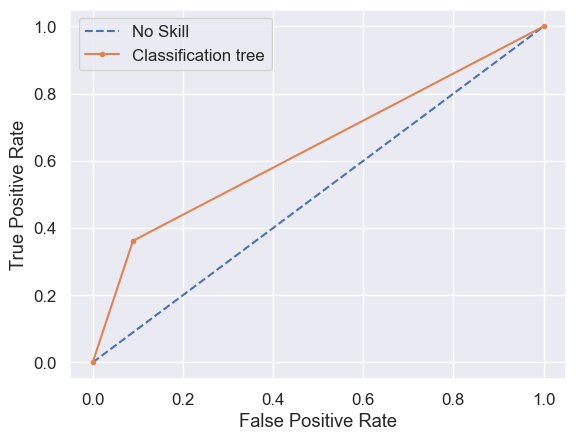

In [65]:
from sklearn.metrics import roc_curve

import matplotlib.pyplot as plt

# Visualisation with plot_metric

ns_fpr, ns_tpr, _ = roc_curve(y_test, ns_probs)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)


# plot the roc curve for the model
plt.plot(ns_fpr, ns_tpr, linestyle='--', label='No Skill')
plt.plot(dt_fpr, dt_tpr, marker='.', label='Classification tree')

# axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

# show the legend
plt.legend()

# show the plot
plt.show()

In [ ]:
#calculate the Area Under the Curve - AUC metric of the tree.

In [67]:
from sklearn.metrics import roc_auc_score
# calculate scores
ns_auc = roc_auc_score(y_test, ns_probs)
dt_auc = roc_auc_score(y_test, dt_probs)
# summarize scores
print('No Skill: ROC AUC=%.3f' % (ns_auc))
print('Classification tree: ROC AUC=%.3f' % (dt_auc))


No Skill: ROC AUC=0.500
Classification tree: ROC AUC=0.636


## Part 3: Classification tree with cross validation and random forest

In [ ]:
#Let now re-calculate a classification tree but with cross validation. 
#Cross validate at least one hyperparameter e.g. max_depth

In [ ]:
#estimate the tree with cross validation

In [69]:
params_dt = {'max_depth': [2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30],
            "min_samples_leaf":[10,20,30,40,50],
            "min_samples_split":[10,20,30,40,50]}

In [71]:
#cross validate the parameters to find the optimal parameters
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

# Instantiate grid_dt
dt_cv = GridSearchCV(estimator=my_tree,
                       param_grid=params_dt,
                       scoring='roc_auc',
                       cv=5,
                       verbose=1,
                       n_jobs=-1)

dt_cv.fit(x_train, y_train)

Fitting 5 folds for each of 725 candidates, totalling 3625 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,
                                       14, 15, 16, 17, 18, 19, 20, 21, 22, 23,
                                       24, 25, 26, 27, 28, 29, 30],
                         'min_samples_leaf': [10, 20, 30, 40, 50],
                         'min_samples_split': [10, 20, 30, 40, 50]},
             scoring='roc_auc', verbose=1)

In [73]:
#check the best model
best_model = dt_cv.best_estimator_
print(best_model)

DecisionTreeClassifier(max_depth=26, min_samples_leaf=50, min_samples_split=10,
                       random_state=42)


In [75]:
#calculate the new predicted values
y_dt_cv_pred = dt_cv.predict(x_test)

In [ ]:
#calculate the confusion matrix

In [77]:
conf_matrix= metrics.confusion_matrix(y_test, y_dt_cv_pred)
print(conf_matrix)

[[39027   967]
 [ 4276   944]]


Text(0.5, -0.6000000000000014, 'Predicted')

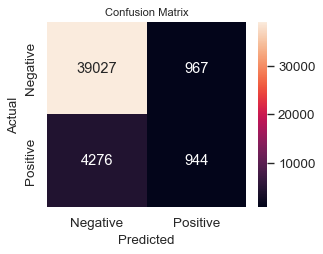

In [79]:
plt.figure(figsize=(4,3), dpi=80)
sns.set(font_scale = 1.1)

ax = sns.heatmap(conf_matrix, annot=True, fmt='d', )
ax.xaxis.set_ticklabels(['Negative', 'Positive'])
ax.yaxis.set_ticklabels(['Negative', 'Positive'])
ax.set_title("Confusion Matrix", fontsize=10)
ax.set_ylabel("Actual", fontsize=12)
ax.set_xlabel("Predicted", fontsize=12)

In [113]:
#Calculate now the forecast from a "no-skill" prediction and the probabilities of the cross validated tree.
#calculate the new probabilities
dt_cv_probs = dt_cv.predict_proba(x_test)[:,1]
ns_probs = [0 for _ in range(len(y_test))]

In [ ]:
#compare the cross - validated tree with the "no-skill" prediction based on the ROC curve. 

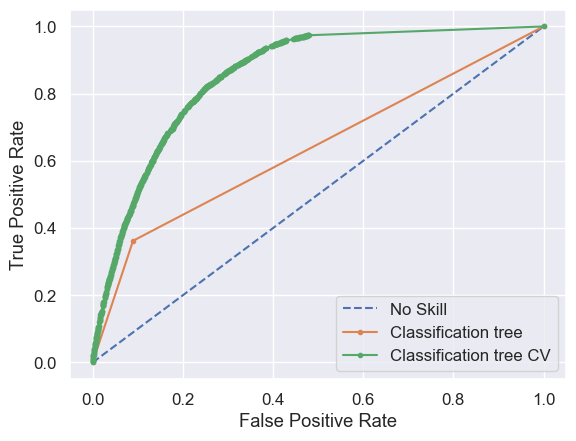

In [105]:
from sklearn.metrics import roc_curve

import matplotlib.pyplot as plt

# Visualisation with plot_metric

ns_fpr, ns_tpr, _ = roc_curve(y_test, ns_probs)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)
dt_cv_fpr, dt_cv_tpr, _ = roc_curve(y_test, dt_cv_probs)

# plot the roc curve for the model
plt.plot(ns_fpr, ns_tpr, linestyle='--', label='No Skill')
plt.plot(dt_fpr, dt_tpr, marker='.', label='Classification tree')
plt.plot(dt_cv_fpr, dt_cv_tpr, marker='.', label='Classification tree CV')

# axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

# show the legend
plt.legend()

# show the plot
plt.show()

In [ ]:
#calculate the Area Under the Curve - AUC metric of the cross validated tree.

In [107]:
from sklearn.metrics import roc_auc_score
# calculate scores
ns_auc = roc_auc_score(y_test, ns_probs)
dt_auc = roc_auc_score(y_test, dt_probs)
dt_cv_auc = roc_auc_score(y_test, dt_cv_probs)
# summarize scores
print('No Skill: ROC AUC=%.3f' % (ns_auc))
print('Classification tree: ROC AUC=%.3f' % (dt_auc))
print("Classification tree CV: ROC AUC=%.3F" % (dt_cv_auc))

No Skill: ROC AUC=0.500
Classification tree: ROC AUC=0.636
Classification tree CV: ROC AUC=0.855


In [ ]:
#Estimate a Random Forest
#We now expand the set of models and include a random forest.
#The goal is to see if a more robust framework allows to have a more precise idea of the mortgage probability of default.

In [109]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(random_state=42,bootstrap=False) 
forest.fit(x_train, y_train)                                        
y_rf_pred = forest.predict(x_test)

In [ ]:
#calculate the confusion matrix

In [110]:
conf_matrix= metrics.confusion_matrix(y_test, y_rf_pred)
print(conf_matrix)

[[38699  1295]
 [ 4128  1092]]


Text(0.5, -0.6000000000000014, 'Predicted')

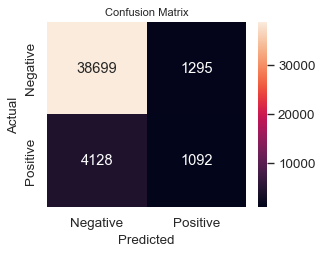

In [91]:
import seaborn as sns
plt.figure(figsize=(4,3), dpi=80)
sns.set(font_scale = 1.1)

ax = sns.heatmap(conf_matrix, annot=True, fmt='d', )
ax.xaxis.set_ticklabels(['Negative', 'Positive'])
ax.yaxis.set_ticklabels(['Negative', 'Positive'])
ax.set_title("Confusion Matrix", fontsize=10)
ax.set_ylabel("Actual", fontsize=12)
ax.set_xlabel("Predicted", fontsize=12)

In [ ]:
#Calculate now the forecast from a "no-skill" prediction and the probabilities of the random forest.

In [93]:
rf_probs = forest.predict_proba(x_test)[:,1]
ns_probs = [0 for _ in range(len(y_test))]

In [ ]:
#compare the random forest with the "no-skill" prediction based on the ROC curve. 

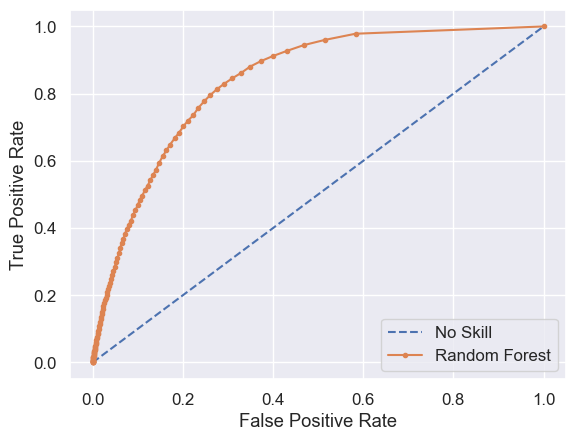

In [95]:
from sklearn.metrics import roc_curve

import matplotlib.pyplot as plt

# Visualisation with plot_metric

ns_fpr, ns_tpr, _ = roc_curve(y_test, ns_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)


# plot the roc curve for the model
plt.plot(ns_fpr, ns_tpr, linestyle='--', label='No Skill')
plt.plot(rf_fpr, rf_tpr, marker='.', label='Random Forest')

# axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

# show the legend
plt.legend()

# show the plot
plt.show()

In [ ]:
#calculate the Area Under the Curve - AUC metric of the random forest.

In [97]:
rf_auc = roc_auc_score(y_test, rf_probs)
print(rf_auc)

0.8386213894727887


## Compare the models

In [ ]:
#compare the logistic Regression, the Classification Tree without cross validation, the classification tree with cross validation
# and the random forest based on the ROC curve.

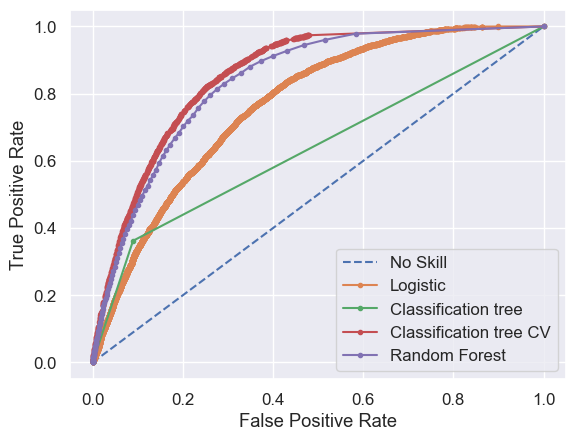

In [99]:
from sklearn.metrics import roc_curve

import matplotlib.pyplot as plt

# Visualisation with plot_metric

ns_fpr, ns_tpr, _ = roc_curve(y_test, ns_probs)
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)
dt_cv_fpr, dt_cv_tpr, _ = roc_curve(y_test, dt_cv_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

# plot the roc curve for the model
plt.plot(ns_fpr, ns_tpr, linestyle='--', label='No Skill')
plt.plot(lr_fpr, lr_tpr, marker='.', label='Logistic')
plt.plot(dt_fpr, dt_tpr, marker='.', label='Classification tree')
plt.plot(dt_cv_fpr, dt_cv_tpr, marker='.', label='Classification tree CV')
plt.plot(rf_fpr, rf_tpr, marker='.', label='Random Forest')

# axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

# show the legend
plt.legend()

# show the plot
plt.show()

In [101]:
from sklearn.metrics import roc_auc_score
# calculate scores
ns_auc = roc_auc_score(y_test, ns_probs)
lr_auc = roc_auc_score(y_test, lr_probs)
dt_auc = roc_auc_score(y_test, dt_probs)
dt_cv_auc = roc_auc_score(y_test, dt_cv_probs)
rf_auc = roc_auc_score(y_test, rf_probs)


# summarize scores
print('No Skill: ROC AUC=%.3f' % (ns_auc))
print('Logistic: ROC AUC=%.3f' % (lr_auc))
print('Classification tree: ROC AUC=%.3f' % (dt_auc))
print("Classification tree CV: ROC AUC=%.3F" % (dt_cv_auc))
print("Random Forest: ROC AUC=%.3F" % (rf_auc))


No Skill: ROC AUC=0.500
Logistic: ROC AUC=0.768
Classification tree: ROC AUC=0.636
Classification tree CV: ROC AUC=0.855
Random Forest: ROC AUC=0.839
